# 1. Über den Datensatz

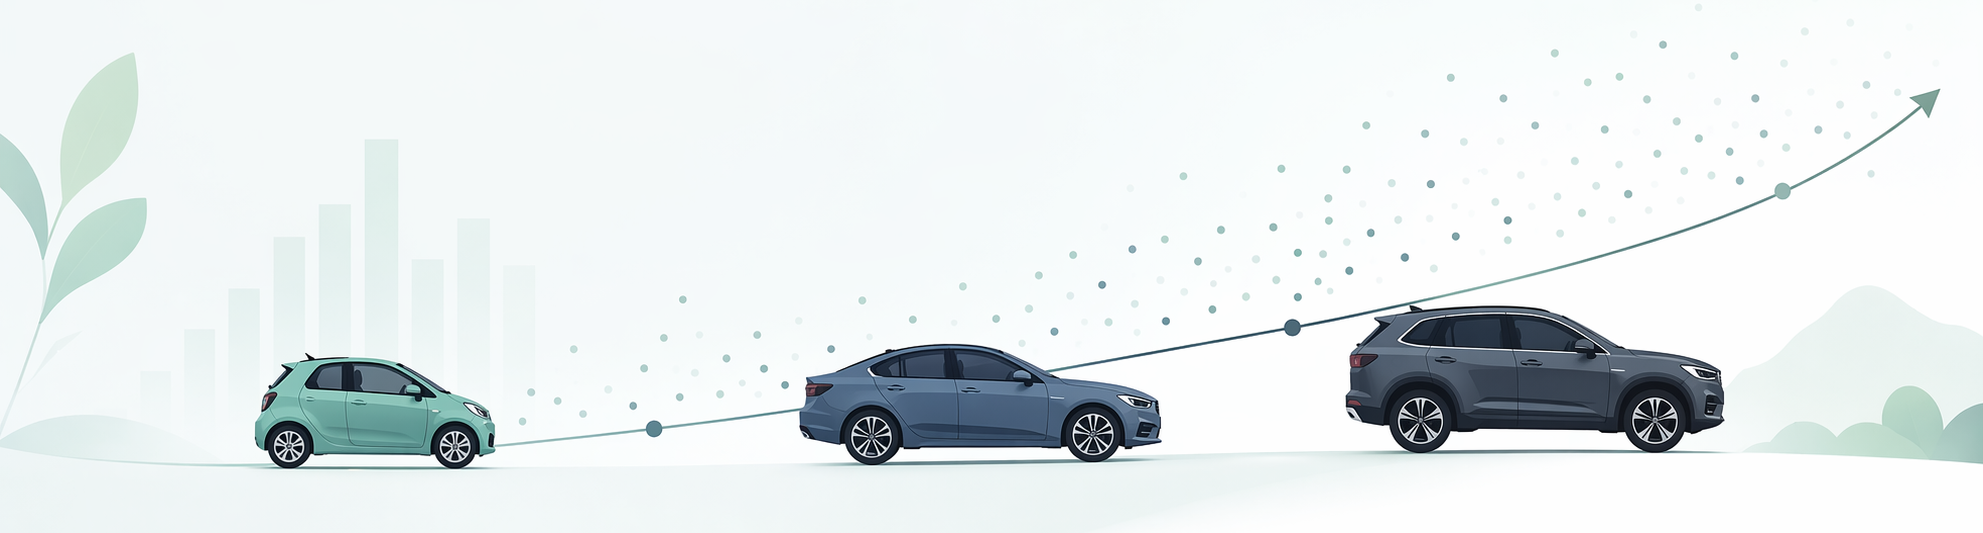

Dieser Datensatz enthält die Kohlendioxid (CO₂)-Emissionen und den Kraftstoffverbrauch verschiedener Fahrzeuge. Im Kontext des maschinellen Lernens wird dieser Datensatz verwendet, um CO₂-Emissionen vorherzusagen oder die Kraftstoffeffizienz von Fahrzeugen zu analysieren. Unser Ziel ist es, basierend auf Fahrzeugeigenschaften die CO₂-Emissionen oder den Kraftstoffverbrauch zu schätzen. Insgesamt gibt es 7.385 Zeilen und 12 Spalten.

**Die Spalten im Datensatz und ihre Beschreibungen:**

1. **Make**: Fahrzeugmarke  
2. **Model**: Fahrzeugmodell  
3. **Vehicle Class**: Fahrzeugklasse  
4. **Engine Size(L)**: Motorgröße  
5. **Cylinders**: Anzahl der Zylinder  
6. **Transmission**: Getriebetyp  
7. **Fuel Type**: Kraftstoffart  
8. **Fuel Consumption City (L/100 km)**: Kraftstoffverbrauch innerorts  
9. **Fuel Consumption Hwy (L/100 km)**: Kraftstoffverbrauch außerorts (Autobahn)  
10. **Fuel Consumption Comb (L/100 km)**: Kombinierter Kraftstoffverbrauch (innerorts und außerorts)  
11. **Fuel Consumption Comb (mpg)**: Kombinierter Kraftstoffverbrauch  
12. **CO2 Emissions(g/km)**: CO₂-Emissionen  

**Model**

- `4WD/4X4`: Allradantrieb  
- `AWD`: Allradantrieb (alle Räder)  
- `FFV`: Flex-Fuel-Fahrzeug  
- `SWB`: Kurzer Radstand  
- `LWB`: Langer Radstand  
- `EWB`: Erweiterter Radstand  

**Transmission**

- `A`: Automatik  
- `AM`: Automatisiertes Schaltgetriebe  
- `AS`: Automatik mit manueller Schaltmöglichkeit  
- `AV`: Stufenloses Getriebe  
- `M`: Manuell  
- `3 - 10`: Anzahl der Gänge  

**Fuel Type**

- `X`: Normalbenzin  
- `Z`: Premiumbenzin  
- `D`: Diesel  
- `E`: Ethanol (E85)  
- `N`: Erdgas  

**Vehicle Class**

- `COMPACT`: Kompaktfahrzeuge  
- `SUV - SMALL`: Kleine SUVs  
- `MID-SIZE`: Mittelklassefahrzeuge  
- `TWO-SEATER`: Zweisitzer  
- `MINICOMPACT`: Sehr kleine Fahrzeuge  
- `SUBCOMPACT`: Kleinwagen unterhalb der Kompaktklasse  
- `FULL-SIZE`: Große Fahrzeuge  
- `STATION WAGON - SMALL`: Kleine Kombifahrzeuge  
- `SUV - STANDARD`: Standard-SUVs  
- `VAN - CARGO`: Transporter für Fracht  
- `VAN - PASSENGER`: Transporter für Personen  
- `PICKUP TRUCK - STANDARD`: Standard-Pick-up-Trucks  
- `MINIVAN`: Kleinbusse  
- `SPECIAL PURPOSE VEHICLE`: Spezialfahrzeuge  
- `STATION WAGON - MID-SIZE`: Mittelgroße Kombifahrzeuge  
- `PICKUP TRUCK - SMALL`: Kleine Pick-up-Trucks  

Dieser in dieser Studie verwendete Datensatz: https://www.kaggle.com/datasets/debajyotipodder/CO2-emission-by-vehicles/data

# 2. Importieren der Bibliotheken

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

%matplotlib inline

warnings.filterwarnings('ignore')

# 3. Laden des Datensatzes

In [2]:
df = pd.read_csv('../data/co2.csv')

df

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232


In [3]:
df2 = df.copy()

# 4. Überblick über den Datensatz

In [4]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
Fuel Consumption Comb (mpg),7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


In [7]:
# Kategorische (object) Spalten können nicht direkt in Machine-Learning-Modelle eingegeben werden.
# Die direkte Umwandlung von kategorialen Spalten mit hoher Kardinalität in numerische Form kann zu unnötiger Feature-Erweiterung führen.
# Dies kann die Modellkomplexität erhöhen und sich negativ auf die Trainingszeit sowie die Rechenkosten auswirken.

df.describe(include='object').T

,count,unique,top,freq
Make,7385,42,FORD,628
Model,7385,2053,F-150 FFV 4X4,32
Vehicle Class,7385,16,SUV - SMALL,1217
Transmission,7385,27,AS6,1324
Fuel Type,7385,5,X,3637


# 5. Datenbereinigung und Vorverarbeitung

In [8]:
df.rename(columns={'Make': 'make',
                   'Model': 'model',
                   'Vehicle Class': 'vehicle_class',
                   'Engine Size(L)': 'engine_size',
                   'Cylinders': 'cylinders',
                   'Transmission': 'transmission',
                   'Fuel Type': 'fuel_type',
                   'Fuel Consumption City (L/100 km)': 'fuel_cons_city',
                   'Fuel Consumption Hwy (L/100 km)': 'fuel_cons_hwy',
                   'Fuel Consumption Comb (L/100 km)': 'fuel_cons_comb',
                   'Fuel Consumption Comb (mpg)': 'fuel_cons_comb_mpg',
                   'CO2 Emissions(g/km)': 'co2'
                  },
          inplace=True
         )

In [9]:
df.columns

Index(['make', 'model', 'vehicle_class', 'engine_size', 'cylinders',
       'transmission', 'fuel_type', 'fuel_cons_city', 'fuel_cons_hwy',
       'fuel_cons_comb', 'fuel_cons_comb_mpg', 'co2'],
      dtype='object')

# 6.1. Make

In [10]:
df.make.unique()

array(['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', 'BENTLEY', 'BMW',
       'BUICK', 'CADILLAC', 'CHEVROLET', 'CHRYSLER', 'DODGE', 'FIAT',
       'FORD', 'GMC', 'HONDA', 'HYUNDAI', 'INFINITI', 'JAGUAR', 'JEEP',
       'KIA', 'LAMBORGHINI', 'LAND ROVER', 'LEXUS', 'LINCOLN', 'MASERATI',
       'MAZDA', 'MERCEDES-BENZ', 'MINI', 'MITSUBISHI', 'NISSAN',
       'PORSCHE', 'RAM', 'ROLLS-ROYCE', 'SCION', 'SMART', 'SRT', 'SUBARU',
       'TOYOTA', 'VOLKSWAGEN', 'VOLVO', 'GENESIS', 'BUGATTI'],
      dtype=object)

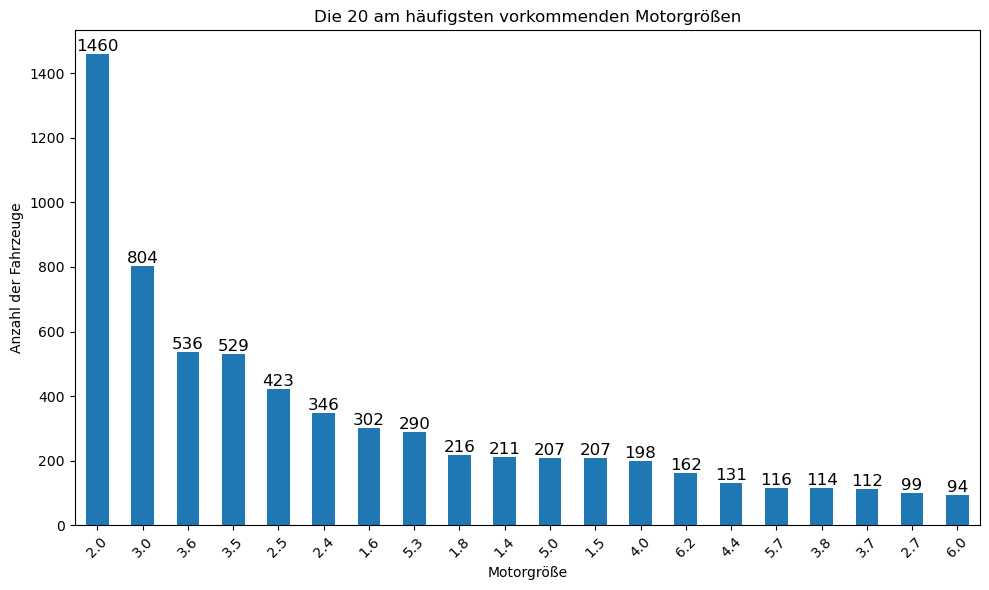

In [11]:
counts = df.engine_size.value_counts().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))

counts.plot(kind='bar', ax=ax)

plt.title('Die 20 am häufigsten vorkommenden Motorgrößen')
plt.xlabel('Motorgröße')
plt.ylabel('Anzahl der Fahrzeuge')
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0], labels=counts.values, fontsize=12)
plt.tight_layout()

plt.show()

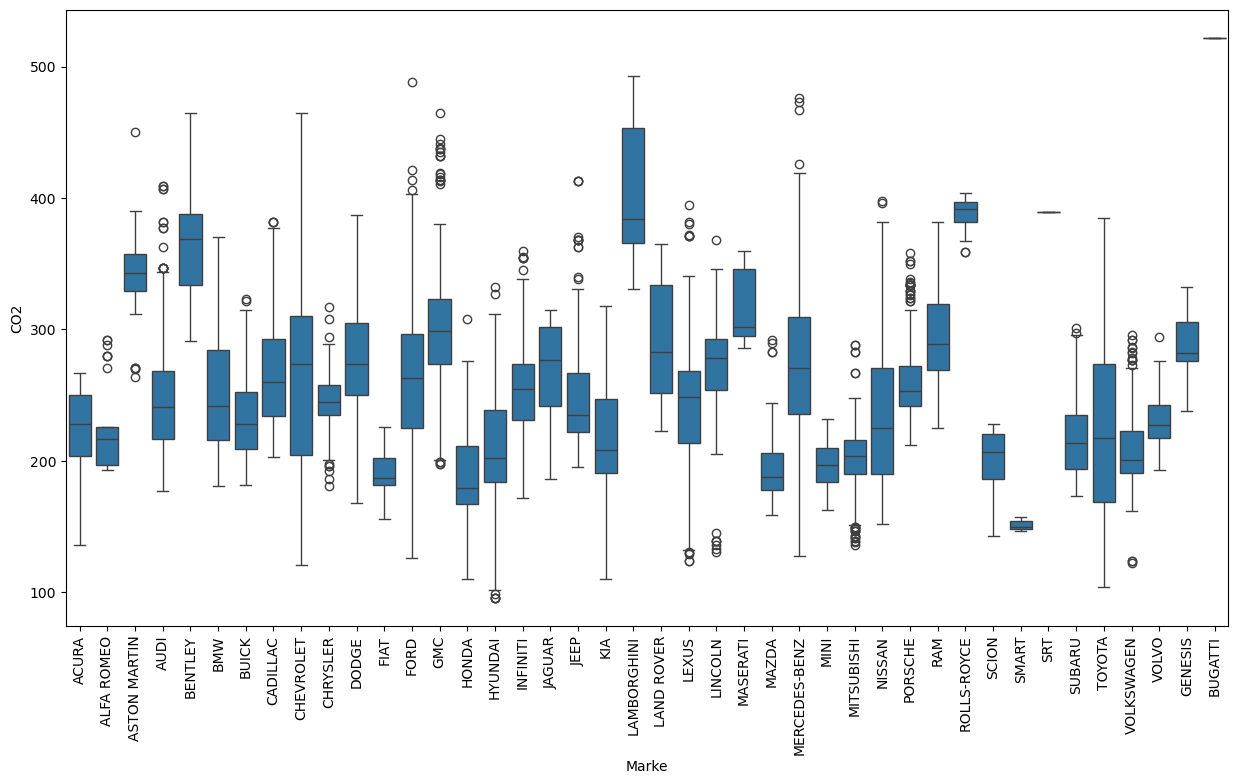

In [12]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df, x='make', y='co2')

plt.xlabel('Marke')
plt.ylabel('CO2')
plt.xticks(rotation=90)

plt.show()

# 6.2. Model

In [13]:
df.model.unique()

array(['ILX', 'ILX HYBRID', 'MDX 4WD', ...,
       'Tacoma 4WD D-Cab TRD Off-Road/Pro', 'Atlas Cross Sport 4MOTION',
       'XC40 T4 AWD'], shape=(2053,), dtype=object)

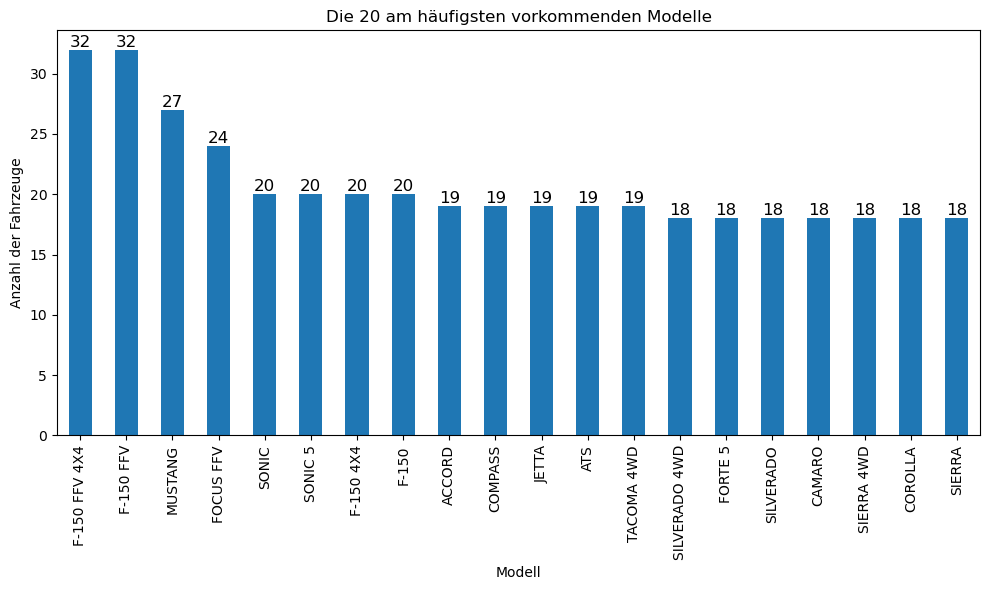

In [14]:
counts = df.model.value_counts().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))

counts.plot(kind='bar', ax=ax)

plt.title('Die 20 am häufigsten vorkommenden Modelle')
plt.xlabel('Modell')
plt.ylabel('Anzahl der Fahrzeuge')
plt.xticks(rotation=90)
ax.bar_label(ax.containers[0], labels=counts.values, fontsize=12)
plt.tight_layout()

plt.show()

# 6.3. Vehicle Class

In [15]:
df.vehicle_class.unique()

array(['COMPACT', 'SUV - SMALL', 'MID-SIZE', 'TWO-SEATER', 'MINICOMPACT',
       'SUBCOMPACT', 'FULL-SIZE', 'STATION WAGON - SMALL',
       'SUV - STANDARD', 'VAN - CARGO', 'VAN - PASSENGER',
       'PICKUP TRUCK - STANDARD', 'MINIVAN', 'SPECIAL PURPOSE VEHICLE',
       'STATION WAGON - MID-SIZE', 'PICKUP TRUCK - SMALL'], dtype=object)

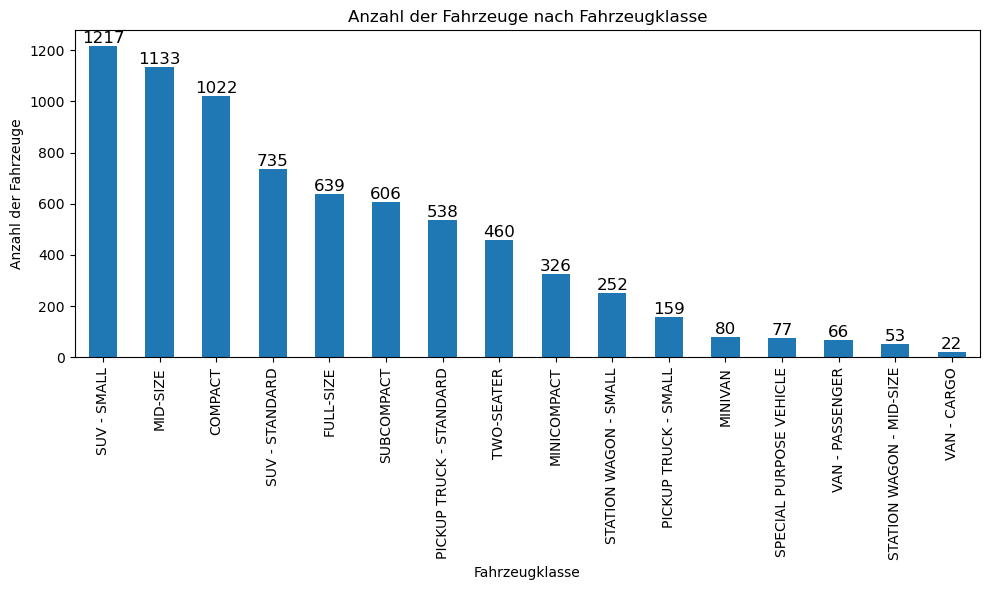

In [16]:
counts = df.vehicle_class.value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

counts.plot(kind='bar', ax=ax)

plt.title('Anzahl der Fahrzeuge nach Fahrzeugklasse')
plt.xlabel('Fahrzeugklasse')
plt.ylabel('Anzahl der Fahrzeuge')
plt.xticks(rotation=90)
ax.bar_label(ax.containers[0], labels=counts.values, fontsize=12)
plt.tight_layout()

plt.show()

# 6.4. Transmission

In [17]:
df.transmission.value_counts().sort_values(ascending=False)

transmission
AS6     1324
AS8     1211
M6       901
A6       789
A8       490
AM7      445
A9       339
AS7      319
AV       295
M5       193
AS10     168
AM6      132
AV7      118
AV6      113
M7        91
A5        84
AS9       77
A4        65
AM8       62
A7        53
AV8       39
A10       31
AS5       26
AV10      11
AM5        4
AM9        3
AS4        2
Name: count, dtype: int64

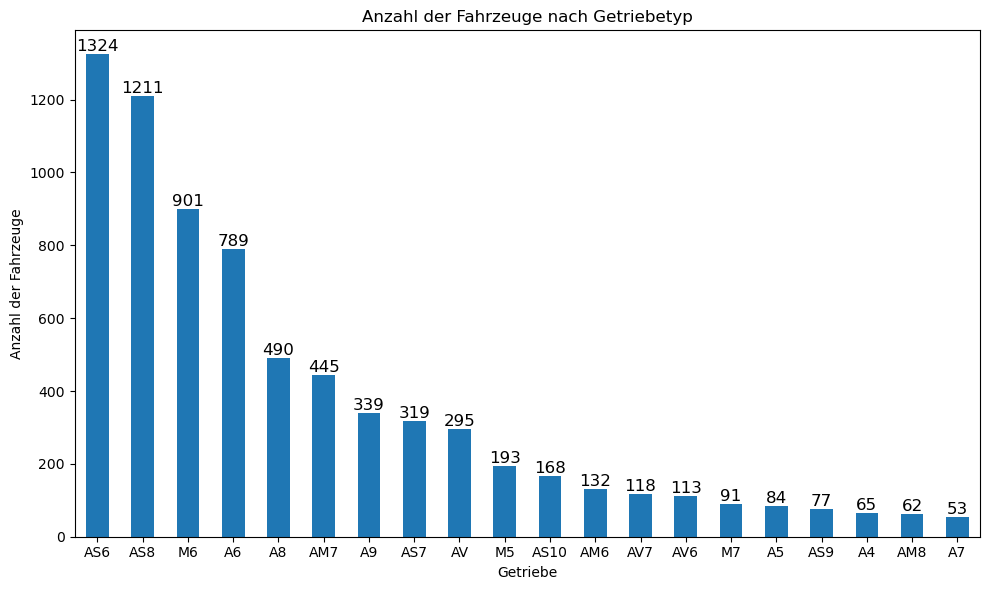

In [18]:
counts = df.transmission.value_counts().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))

counts.plot(kind='bar', ax=ax)

plt.title('Anzahl der Fahrzeuge nach Getriebetyp')
plt.xlabel('Getriebe')
plt.ylabel('Anzahl der Fahrzeuge')
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0], labels=counts.values, fontsize=12)
plt.tight_layout()

plt.show()

# 6.5. Fuel Type

In [19]:
df.fuel_type.value_counts()

fuel_type
X    3637
Z    3202
E     370
D     175
N       1
Name: count, dtype: int64

In [20]:
df[df['fuel_type'] == 'N']

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,fuel_cons_comb_mpg,co2
2439,CHEVROLET,IMPALA DUAL FUEL,MID-SIZE,3.6,6,AS6,N,15.2,9.5,12.7,22,213


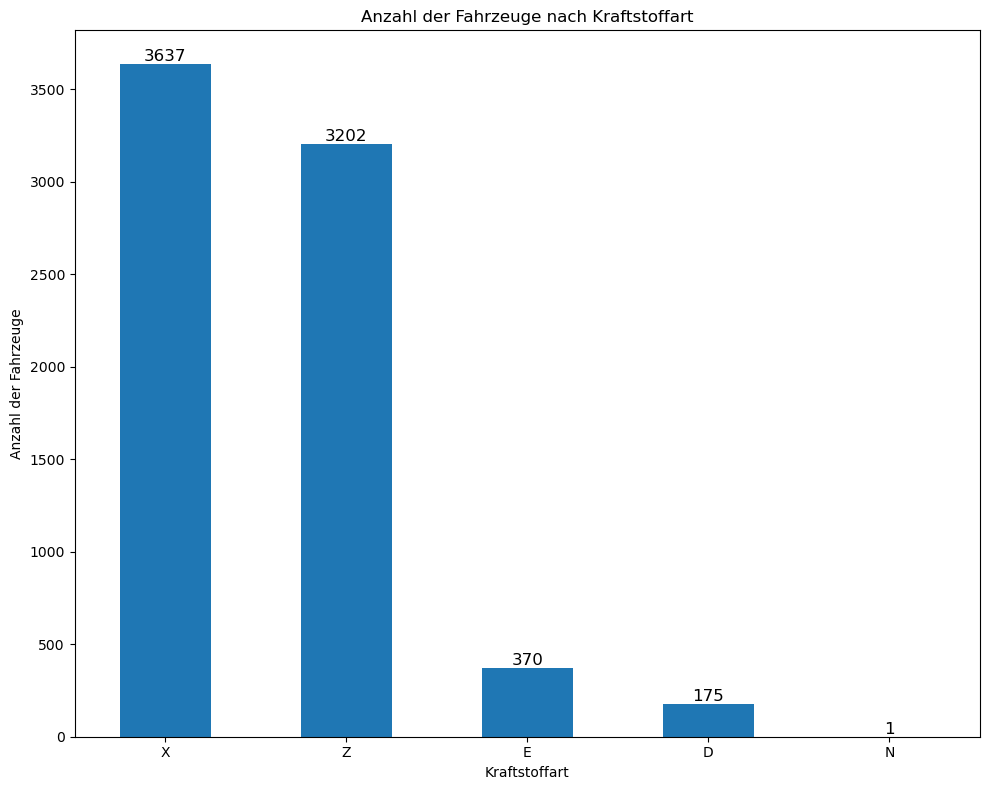

In [21]:
counts = df.fuel_type.value_counts().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))

counts.plot(kind='bar', ax=ax)

plt.title('Anzahl der Fahrzeuge nach Kraftstoffart')
plt.xlabel('Kraftstoffart')
plt.ylabel('Anzahl der Fahrzeuge')
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0], labels=counts.values, fontsize=12)
plt.tight_layout()

plt.show()

# 7. Vor dem Modellieren

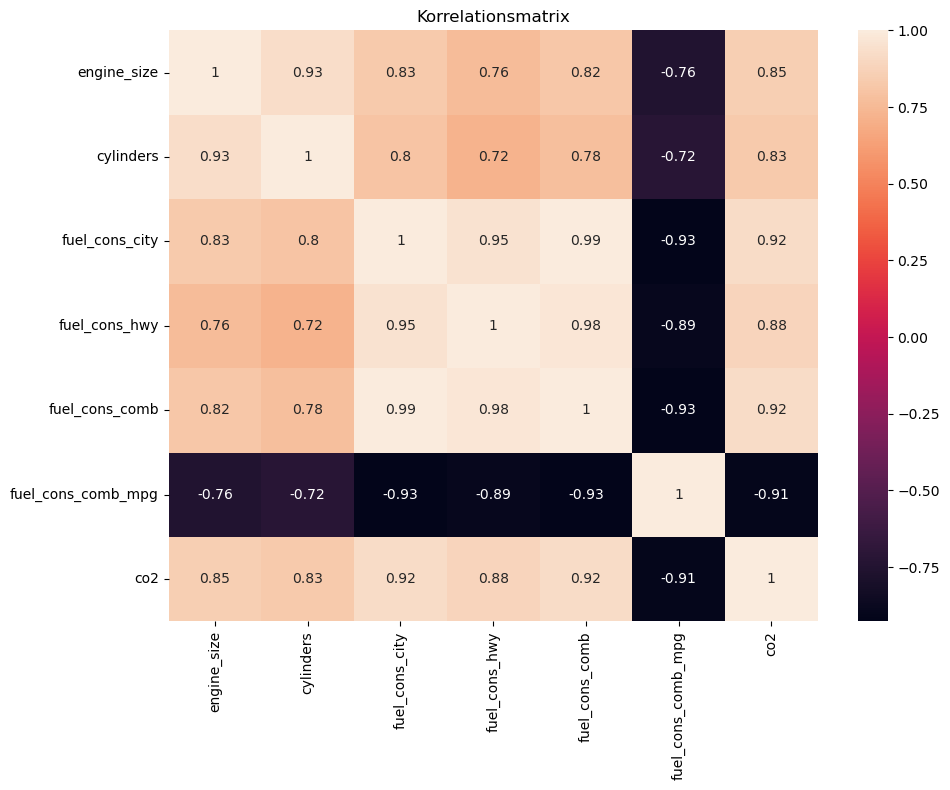

In [22]:
corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr, annot=True, ax=ax)

plt.title('Korrelationsmatrix')
plt.tight_layout()

plt.show()

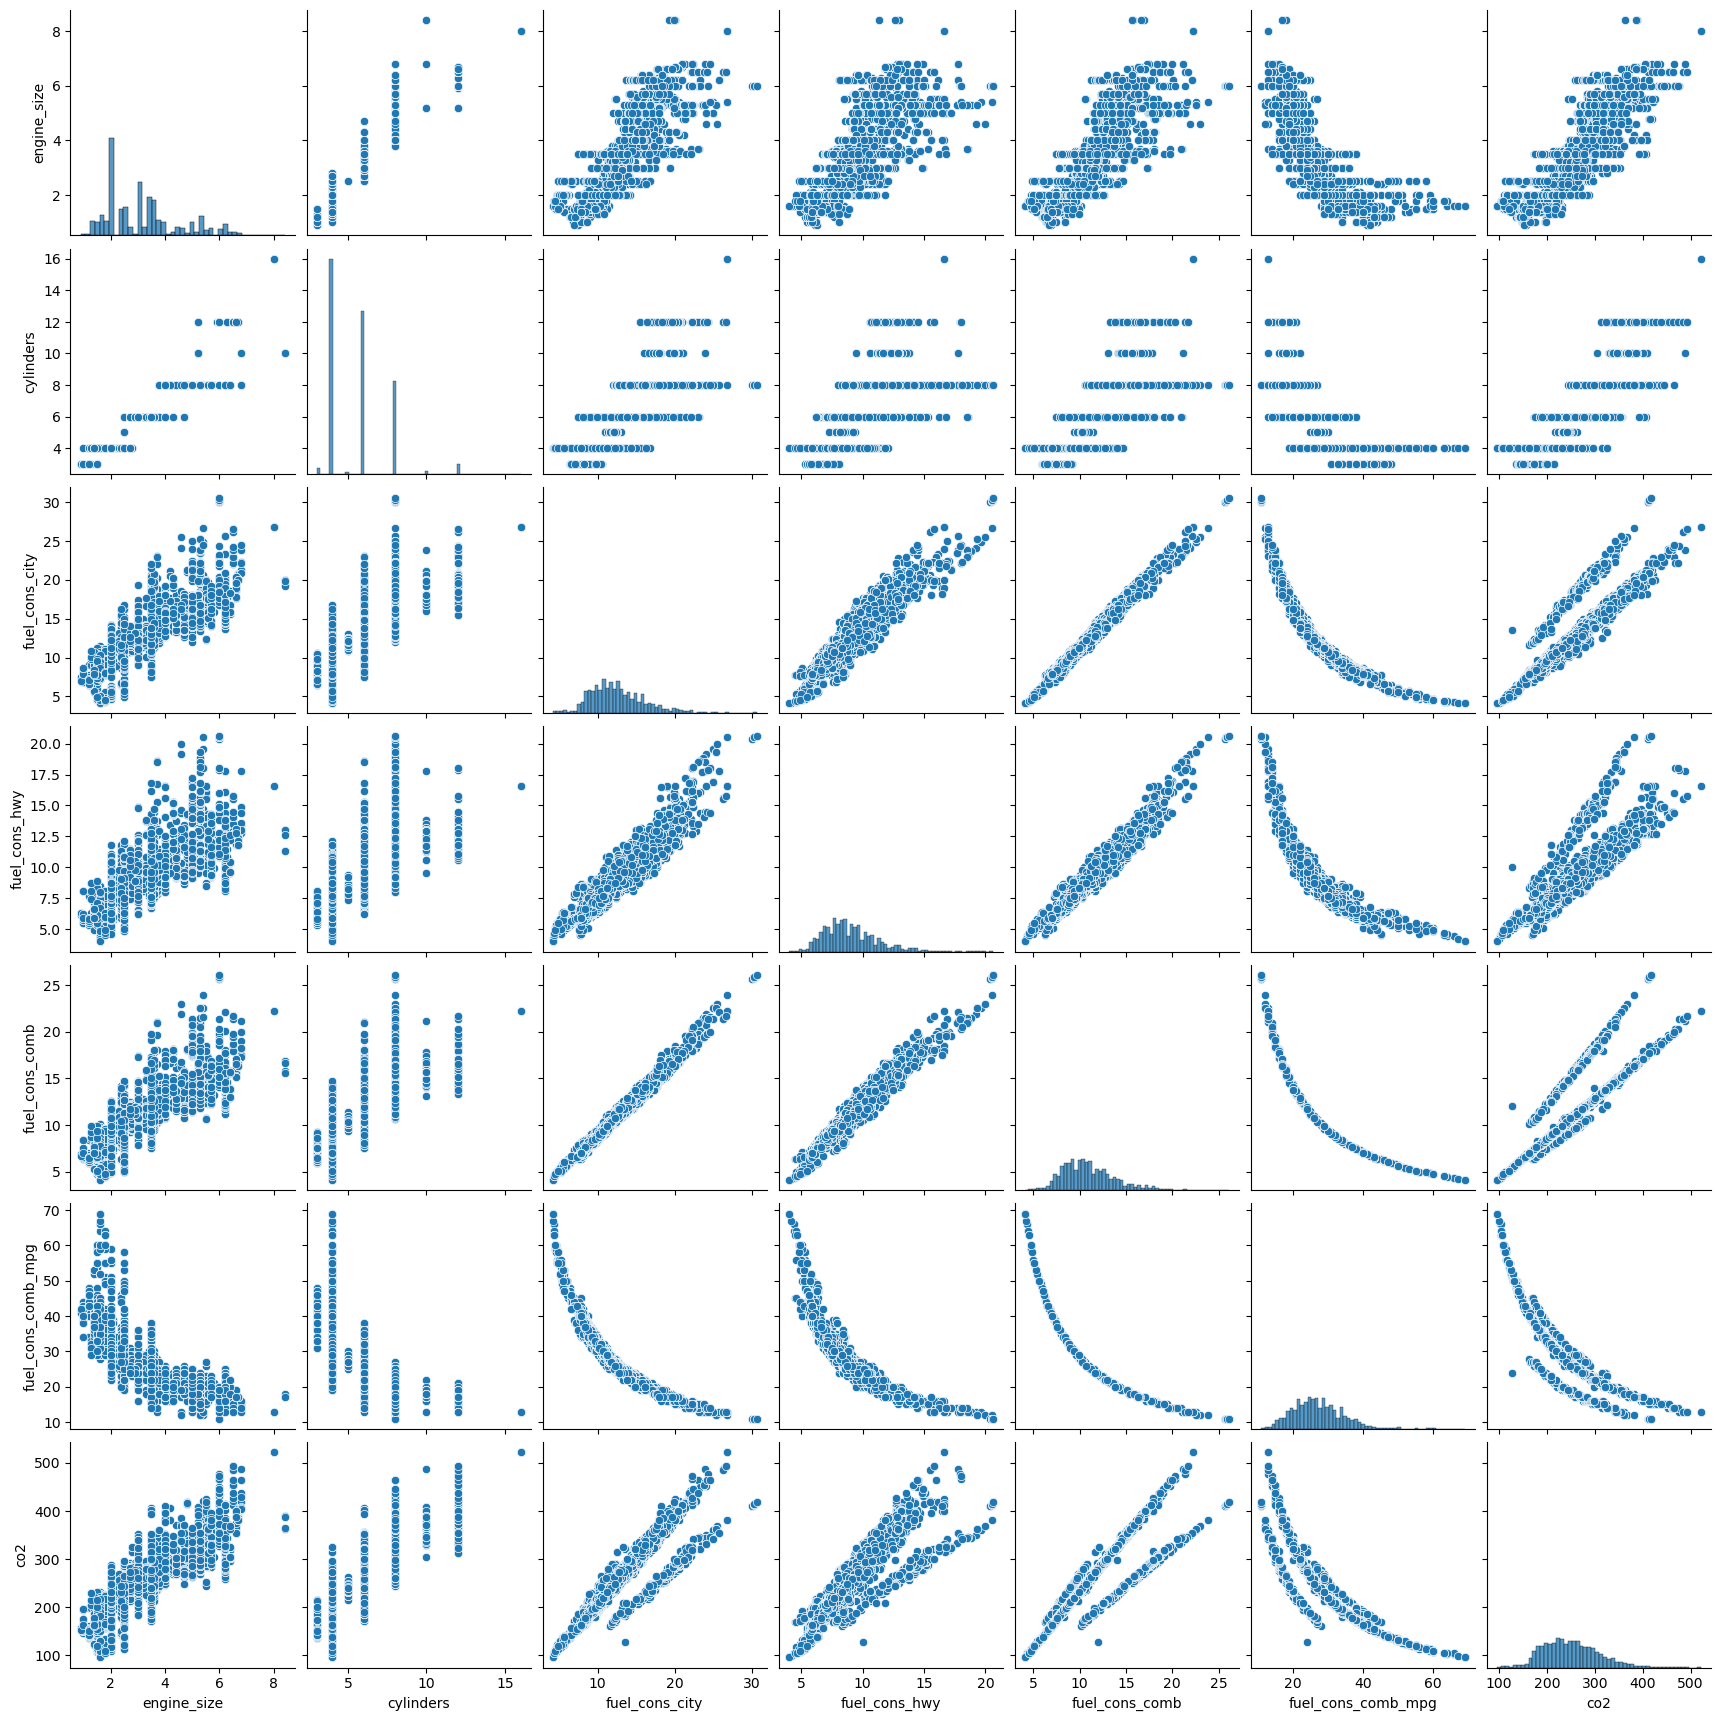

In [23]:
# Für das einfache lineare Regressionsmodell müssen wir eine einzelne Variable auswählen.
# Die Motorgröße weist eine lineare Beziehung zu den CO₂-Emissionen auf.
# Daher werden wir die Motorgröße als einzige Variable für das einfache lineare Regressionsmodell auswählen.

sns.pairplot(df.select_dtypes(include='number'))

plt.show()

# 8. Einfaches Lineares Regressionsmodell

In [24]:
corr = df.co2.corr(df.engine_size)

corr

np.float64(0.8511446437900009)

In [25]:
r2_score = corr**2

r2_score

np.float64(0.7244472046524075)

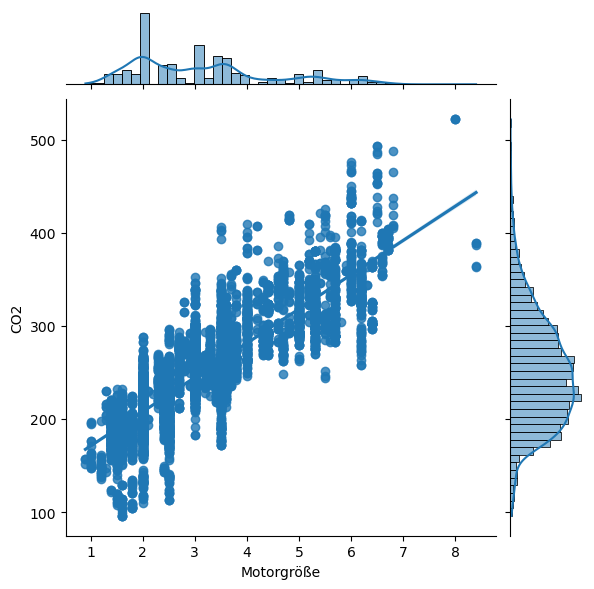

In [26]:
sns.jointplot(data=df.dropna(), x='engine_size', y='co2', kind='reg')

plt.xlabel('Motorgröße')
plt.ylabel('CO2')

plt.show()

In [27]:
X = df[['engine_size']] 
y = df['co2']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [30]:
print('Form der Trainingsmerkmale:', X_train.shape)
print('Form der Trainingszielvariable:', y_train.shape)
print('Form der Testmerkmale:', X_test.shape)
print('Form der Testzielvariable:', y_test.shape)

Form der Trainingsmerkmale: (5908, 1)
Form der Trainingszielvariable: (5908,)
Form der Testmerkmale: (1477, 1)
Form der Testzielvariable: (1477,)


In [31]:
from sklearn.linear_model import LinearRegression  

In [32]:
slr = LinearRegression()

In [33]:
slr.fit(X_train, y_train) 

LinearRegression()

In [34]:
slr.coef_

array([36.70483532])

In [35]:
slr.intercept_

np.float64(134.57376563227777)

In [36]:
y_train_pred = slr.predict(X_train)

In [37]:
y_pred = slr.predict(X_test)

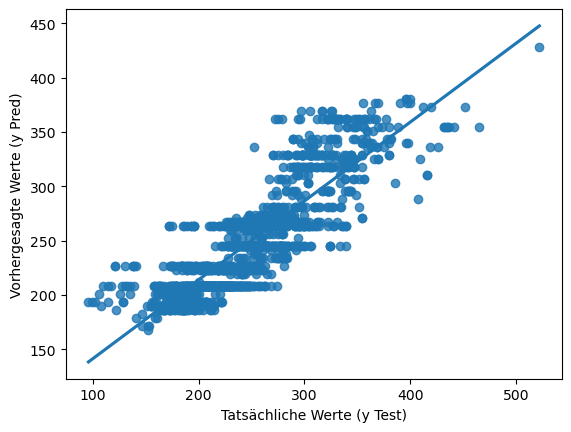

In [38]:
sns.regplot(x=y_test, y=y_pred, ci=None)

plt.xlabel('Tatsächliche Werte (y Test)')
plt.ylabel('Vorhergesagte Werte (y Pred)')

plt.show()

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
def train_val(y_train, y_train_pred, y_test, y_pred, model_name):
    scores = {model_name + '_train': {'R2': r2_score(y_train, y_train_pred),
    'mae': mean_absolute_error(y_train, y_train_pred),
    'mse': mean_squared_error(y_train, y_train_pred),                          
    'rmse': np.sqrt(mean_squared_error(y_train, y_train_pred))},
    model_name + '_test': {'R2': r2_score(y_test, y_pred),
    'mae': mean_absolute_error(y_test, y_pred),
    'mse': mean_squared_error(y_test, y_pred),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred))}}
    return pd.DataFrame(scores)

In [41]:
slr_score = train_val(y_train, y_train_pred, y_test, y_pred, 's_linear')

slr_score 

,s_linear_train,s_linear_test
R2,0.722168,0.733527
mae,23.347037,23.025089
mse,950.918477,912.834643
rmse,30.836966,30.213153


In [42]:
avg_em = df['co2'].mean()

avg_em

np.float64(250.58469871360867)

In [43]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

rmse

np.float64(30.21315347684375)

In [44]:
# Bei jeder Vorhersage besteht ein Fehler von etwa 12 %.

rmse / avg_em

np.float64(0.12057062395247896)

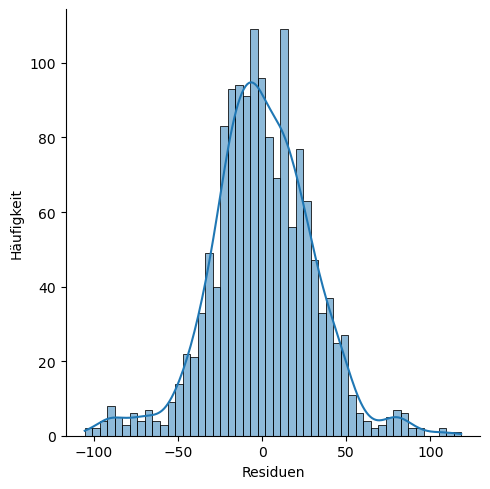

In [45]:
sns.displot((y_test - y_pred), bins=50, kde=True)

plt.xlabel('Residuen')
plt.ylabel('Häufigkeit')

plt.show()

In [46]:
from yellowbrick.regressor import PredictionError

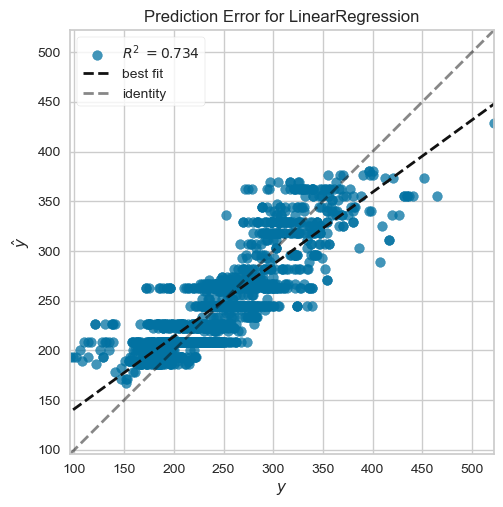

In [47]:
model = LinearRegression()
visualizer = PredictionError(model)

visualizer.fit(X_train, y_train)    
visualizer.score(X_test, y_test)

visualizer.show();

# 9. Multiples Lineares Regressionsmodell

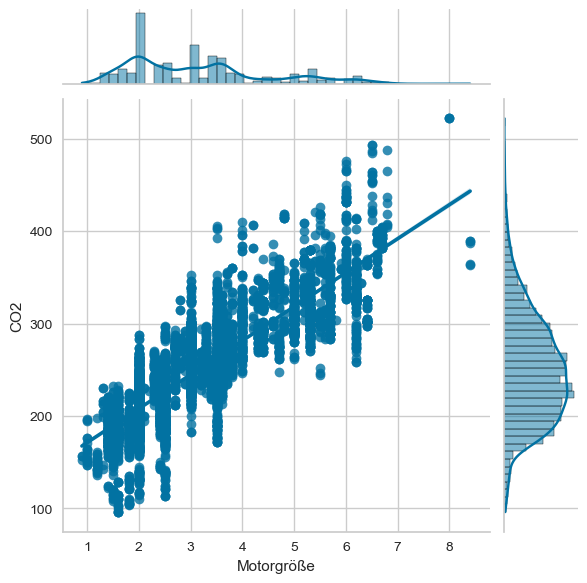

In [48]:
sns.jointplot(x=df['engine_size'], y=df['co2'], kind='reg')

plt.xlabel('Motorgröße')
plt.ylabel('CO2')

plt.show()

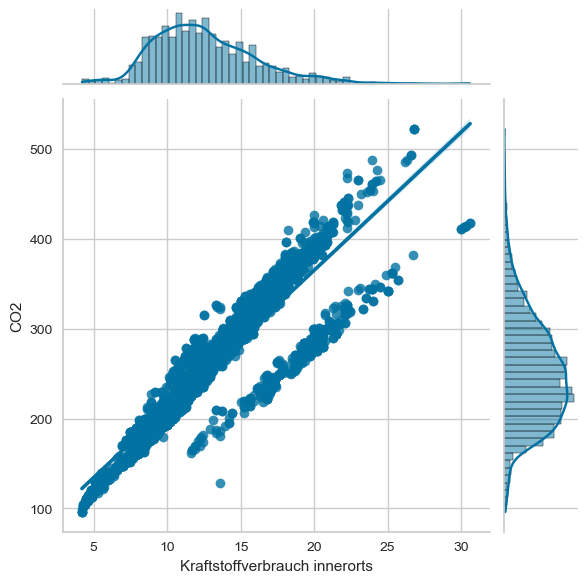

In [49]:
sns.jointplot(x=df['fuel_cons_city'], y=df['co2'], kind='reg')

plt.xlabel('Kraftstoffverbrauch innerorts')
plt.ylabel('CO2')

plt.show()

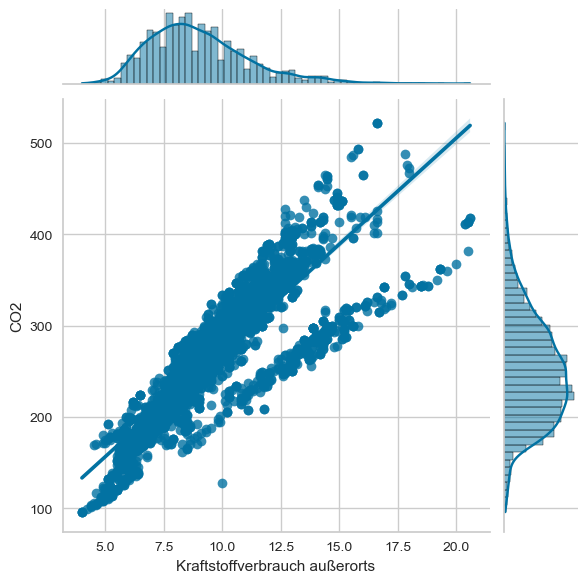

In [50]:
sns.jointplot(x=df['fuel_cons_hwy'], y=df['co2'], kind='reg')

plt.xlabel('Kraftstoffverbrauch außerorts')
plt.ylabel('CO2')

plt.show()

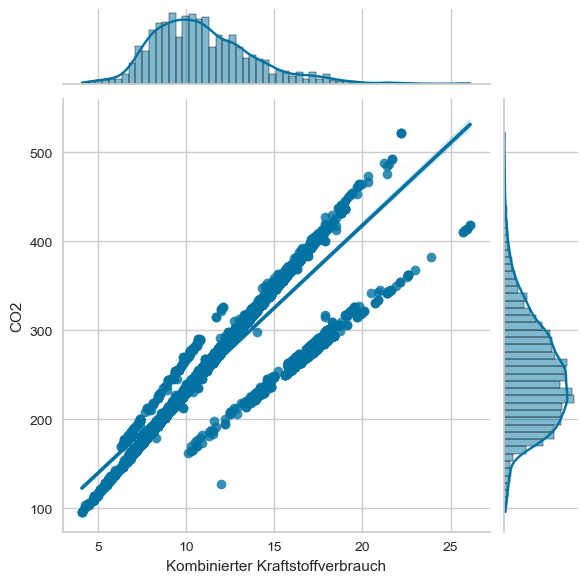

In [51]:
sns.jointplot(x=df['fuel_cons_comb'], y=df['co2'], kind='reg')

plt.xlabel('Kombinierter Kraftstoffverbrauch')
plt.ylabel('CO2')

plt.show()

In [52]:
X = df[['engine_size', 'fuel_cons_city', 'fuel_cons_hwy', 'fuel_cons_comb']] 
y = df['co2']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [54]:
print('Form der Trainingsmerkmale:', X_train.shape)
print('Form der Trainingszielvariable:', y_train.shape)
print('Form der Testmerkmale:', X_test.shape)
print('Form der Testzielvariable:', y_test.shape)

Form der Trainingsmerkmale: (5908, 4)
Form der Trainingszielvariable: (5908,)
Form der Testmerkmale: (1477, 4)
Form der Testzielvariable: (1477,)


In [55]:
mlr = LinearRegression()

In [56]:
mlr.fit(X_train, y_train)

LinearRegression()

In [57]:
mlr.coef_

array([12.78705771,  3.70508653,  0.86566237,  8.51126305])

In [58]:
mlr.intercept_

np.float64(62.343683155431336)

In [59]:
y_train_pred = mlr.predict(X_train)

In [60]:
y_pred = mlr.predict(X_test)

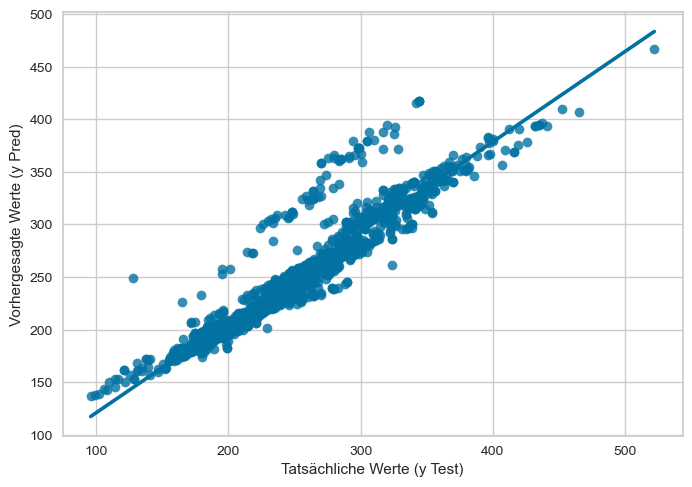

In [61]:
data = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

sns.regplot(data=data, x='y_test', y='y_pred', ci=None)

plt.xlabel('Tatsächliche Werte (y Test)')
plt.ylabel('Vorhergesagte Werte (y Pred)')

plt.show()

In [62]:
avg_em= df['co2'].mean()

avg_em

np.float64(250.58469871360867)

In [63]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

rmse

np.float64(20.929893922610074)

In [64]:
# Bei jeder Vorhersage besteht ein Fehler von etwa 8 %.

rmse / avg_em

np.float64(0.08352422965190978)

In [65]:
y_pred = mlr.predict(X_test)
y_train_pred = mlr.predict(X_train)

In [66]:
train_val(y_train, y_train_pred, y_test, y_pred, 'm_linear')

,m_linear_train,m_linear_test
R2,0.874045,0.872122
mae,13.540126,13.628374
mse,431.098224,438.060460
rmse,20.762905,20.929894


In [67]:
from sklearn.metrics import get_scorer_names

scorers = get_scorer_names()

print(scorers)

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

In [68]:
from sklearn.model_selection import cross_validate, cross_val_score

In [69]:
model = LinearRegression()

In [70]:
scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_root_mean_squared_error'],
                        cv=10,
                        return_train_score=True
                       )

In [71]:
pd.DataFrame(scores, index=range(1, 11))

,fit_time,score_time,test_r2,train_r2,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error
1,0.009738,0.010584,0.845996,0.877158,-14.705346,-13.350694,-533.607232,-419.763931,-23.099940,-20.488141
2,0.008058,0.009255,0.881622,0.873194,-12.926039,-13.556939,-402.538108,-434.302304,-20.063352,-20.839921
3,0.006210,0.004864,0.873872,0.874028,-13.991974,-13.495024,-428.489269,-431.447811,-20.699982,-20.771322
4,0.006005,0.004651,0.842741,0.877209,-14.350799,-13.309812,-500.479278,-423.542806,-22.371394,-20.580156
5,0.006133,0.004671,0.888508,0.872538,-12.506305,-13.735338,-355.408974,-439.573973,-18.852294,-20.966019
6,0.006096,0.004785,0.880078,0.873256,-13.121450,-13.619514,-411.511070,-433.297572,-20.285736,-20.815801
7,0.006370,0.004611,0.880876,0.873128,-13.904079,-13.593875,-441.719431,-430.002590,-21.017122,-20.736504
8,0.009683,0.004476,0.881415,0.873168,-13.140883,-13.615354,-397.332904,-434.896854,-19.933211,-20.854181
9,0.006023,0.004617,0.881354,0.873216,-13.325219,-13.591510,-408.574300,-433.618186,-20.213221,-20.823501
10,0.004793,0.004786,0.876151,0.873645,-13.539683,-13.526826,-441.038795,-430.023223,-21.000924,-20.737001


In [72]:
scores = pd.DataFrame(scores, index=range(1, 11))

scores.iloc[:, 2:].mean()

test_r2                                0.873261
train_r2                               0.874054
test_neg_mean_absolute_error         -13.551178
train_neg_mean_absolute_error        -13.539489
test_neg_mean_squared_error         -432.069936
train_neg_mean_squared_error        -431.046925
test_neg_root_mean_squared_error     -20.753718
train_neg_root_mean_squared_error    -20.761255
dtype: float64

In [73]:
mlr_score = train_val(y_train, y_train_pred, y_test, y_pred, 'm_linear')

mlr_score

,m_linear_train,m_linear_test
R2,0.874045,0.872122
mae,13.540126,13.628374
mse,431.098224,438.060460
rmse,20.762905,20.929894


In [74]:
# Es wird beobachtet, dass das multiple lineare Regressionsmodell effizienter ist.

pd.concat([slr_score, mlr_score], axis=1)

,s_linear_train,s_linear_test,m_linear_train,m_linear_test
R2,0.722168,0.733527,0.874045,0.872122
mae,23.347037,23.025089,13.540126,13.628374
mse,950.918477,912.834643,431.098224,438.060460
rmse,30.836966,30.213153,20.762905,20.929894


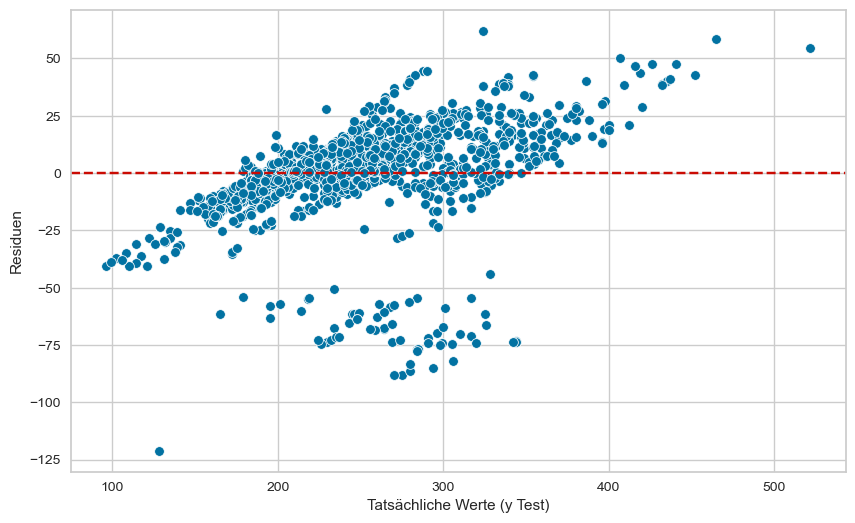

In [75]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=residuals)

plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Tatsächliche Werte (y Test)')
plt.ylabel('Residuen')

plt.show()

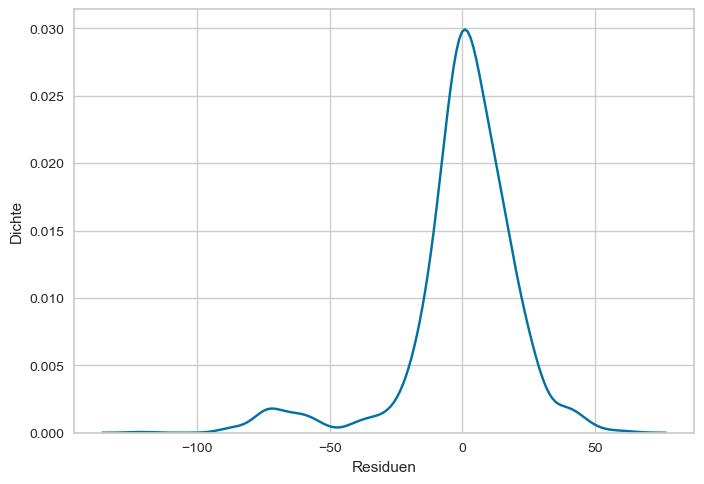

In [76]:
sns.kdeplot(residuals)

plt.xlabel('Residuen')
plt.ylabel('Dichte')

plt.show()

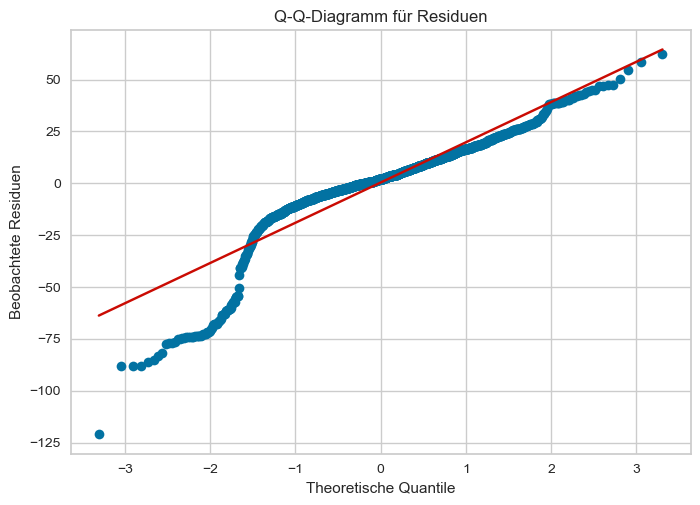

In [77]:
import scipy.stats as stats

stats.probplot(residuals, dist='norm', plot=plt)

plt.title('Q-Q-Diagramm für Residuen')
plt.xlabel('Theoretische Quantile')
plt.ylabel('Beobachtete Residuen')

plt.show()

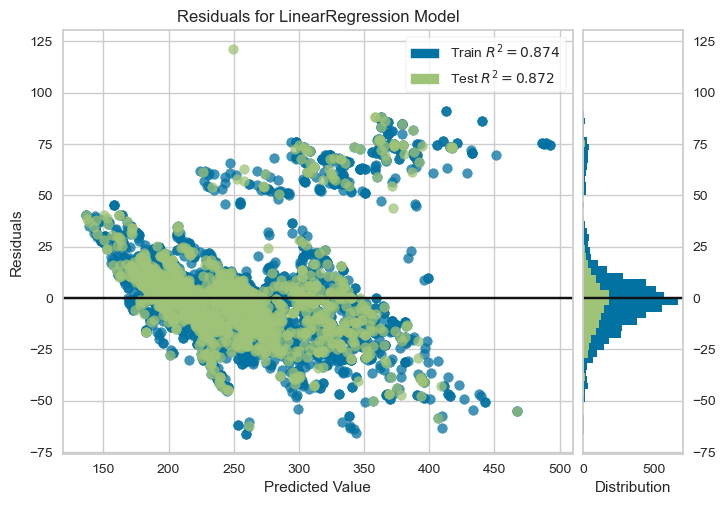

In [78]:
from yellowbrick.regressor import ResidualsPlot

model = LinearRegression()
visualizer = ResidualsPlot(model)

visualizer.fit(X_train, y_train) 
visualizer.score(X_test, y_test) 

visualizer.show();

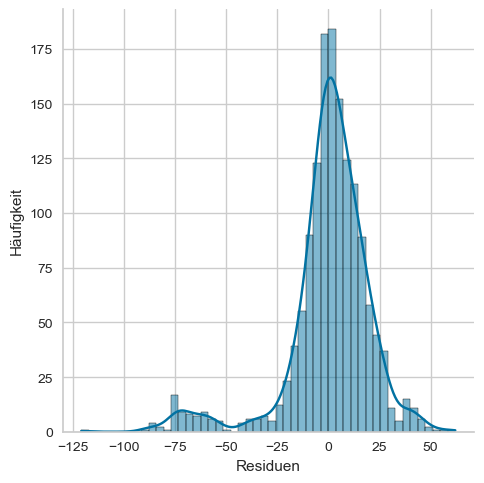

In [79]:
sns.displot((y_test - y_pred), bins=50, kde=True)

plt.xlabel('Residuen')
plt.ylabel('Häufigkeit')

plt.show()

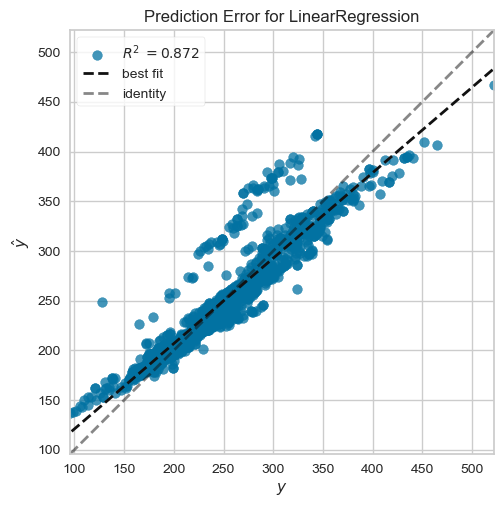

In [80]:
model = LinearRegression()
visualizer = PredictionError(model)

visualizer.fit(X_train, y_train)  
visualizer.score(X_test, y_test)

visualizer.show();

# 10. Final Model

In [81]:
final_model = LinearRegression()

In [82]:
final_model.fit(X, y)

LinearRegression()

In [83]:
final_model.coef_

array([12.83782801,  2.97503146,  0.83187809,  9.4575278 ])

In [84]:
final_model.intercept_

np.float64(61.341573669161875)

In [85]:
X.loc[[3711, 5976]]

,engine_size,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb
3711,5.0,15.8,9.8,13.1
5976,3.0,11.9,8.5,10.4


In [86]:
new_data = [[5.0, 15.8, 9.8, 13.1], [3.0, 11.9, 8.5, 10.4]]

new_data

[[5.0, 15.8, 9.8, 13.1], [3.0, 11.9, 8.5, 10.4]]

In [87]:
final_model.predict(new_data)

array([304.58223016, 240.68718489])

In [88]:
df.loc[[3711, 5976]]

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_cons_city,fuel_cons_hwy,fuel_cons_comb,fuel_cons_comb_mpg,co2
3711,FORD,MUSTANG,SUBCOMPACT,5.0,8,M6,X,15.8,9.8,13.1,22,307
5976,JAGUAR,F-TYPE Coupe,TWO-SEATER,3.0,6,AS8,Z,11.9,8.5,10.4,27,242


In [89]:
307 - 304.58223016

2.4177698400000054

In [90]:
242 - 240.68718489

1.3128151100000025

In [91]:
y_pred_final = final_model.predict(X)

y_pred_final

array([202.43261059, 222.67044135, 159.07281134, ..., 226.39178562,
       220.87169534, 231.74550027], shape=(7385,))

In [92]:
my_dict = {'actual': y, 'pred': y_pred_final, 'residual': y - y_pred_final}

compare = pd.DataFrame(my_dict)

compare.head(20)

,actual,pred,residual
0,196,202.432611,-6.432611
1,221,222.670441,-1.670441
2,136,159.072811,-23.072811
3,255,256.605520,-1.605520
4,244,249.758986,-5.758986
5,230,242.657585,-12.657585
6,232,243.638586,-11.638586
7,255,259.387401,-4.387401
8,267,266.317123,0.682877
9,212,216.936036,-4.936036


In [93]:
engine_size = 2.0
fuel_cons_city = 8.2
fuel_cons_hwy = 6.5
fuel_cons_comb = 7.7

In [94]:
X = np.array([[engine_size, fuel_cons_city, fuel_cons_hwy, fuel_cons_comb]])

CO2 = final_model.predict(X)
CO2 = np.squeeze(CO2).round(1)

oran = rmse / avg_em  
dogruluk_orani = ((1 - oran) * 100).round(1)

print('Die CO₂-Emission dieses Fahrzeugs wird mit', dogruluk_orani, '% Genauigkeit bei etwa', CO2, 'g/km liegen.')

Die CO₂-Emission dieses Fahrzeugs wird mit 91.6 % Genauigkeit bei etwa 189.6 g/km liegen.
